In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import math

In [3]:
# Find all results
RESULTS_DIR = Path("/work/kz133/yapper/experiments/experiment5_language_mixing/results")
experiments = [p for p in RESULTS_DIR.iterdir() if p.is_dir()]
print(len(experiments))

72


In [4]:
all_results = []

# Get evaluation results if available
for experiment in experiments:
    results_path = experiment / "eval_results.json"
    metadata_path = experiment / "metadata.json"
    
    experiment_data = {
        "experiment_name": experiment.name,
    }

    if metadata_path.exists():
        with open(metadata_path, "r") as f:
            metadata = json.load(f)
        
        experiment_data["max_seq_length"] = metadata.get("max_seq_length")
        experiment_data["lora_rank"] = metadata.get("lora_rank")
        experiment_data["model_name"] = metadata.get("model_name")
        
        if "training_params" in metadata:
            experiment_data["learning_rate"] = metadata["training_params"].get("learning_rate")
            experiment_data["gradient_accumulation_steps"] = metadata["training_params"].get("gradient_accumulation_steps")
        
        # Prioritize metadata for configuration parameters if they exist
        experiment_data["lambda_qa"] = metadata.get("lambda_qa")
        experiment_data["num_qa_samples"] = metadata.get("num_qa_samples")

    if results_path.exists():
        with open(results_path, "r") as f:
            results = json.load(f)
        
        # If lambda_qa or num_qa_samples were not in metadata, get them from results
        if "lambda_qa" not in experiment_data or experiment_data["lambda_qa"] is None:
            experiment_data["lambda_qa"] = results.get("lambda_qa")
        if "num_qa_samples" not in experiment_data or experiment_data["num_qa_samples"] is None:
            experiment_data["num_qa_samples"] = results.get("num_qa_samples")

        experiment_data["avg_qa_accuracy"] = results.get("avg_qa_accuracy")
        experiment_data["avg_length_reward"] = results.get("avg_length_reward")
        experiment_data["avg_compression_ratio"] = results.get("avg_compression_ratio")
        experiment_data["avg_overall_reward"] = results.get("avg_overall_reward")
        
        all_results.append(experiment_data)

results_df = pd.DataFrame(all_results)

In [5]:
results_df.sort_values(by="avg_qa_accuracy", ascending=False).head(10)

,experiment_name,max_seq_length,lora_rank,model_name,learning_rate,gradient_accumulation_steps,lambda_qa,num_qa_samples,avg_qa_accuracy,avg_length_reward,avg_compression_ratio,avg_overall_reward
15,sweep_learning_rate_1eneg04_lora_rank_32_gradi...,2048,32,unsloth/Qwen3-4B-Instruct-2507,0.00010,4,-1.0,2,0.917,-0.042218,0.990620,-0.078958
7,sweep_learning_rate_1eneg04_lora_rank_16_gradi...,2048,16,unsloth/Qwen3-4B-Instruct-2507,0.00010,4,-1.0,2,0.902,0.003633,1.049938,-0.040449
47,sweep_learning_rate_2eneg05_lora_rank_8_gradie...,2048,8,unsloth/Qwen3-4B-Instruct-2507,0.00002,4,-1.0,2,0.775,0.535591,3.186059,0.180560
69,sweep_learning_rate_5eneg05_lora_rank_8_gradie...,2048,8,unsloth/Qwen3-4B-Instruct-2507,0.00005,4,-0.5,2,0.749,0.751967,4.602157,0.431883
54,sweep_learning_rate_5eneg05_lora_rank_16_gradi...,2048,16,unsloth/Qwen3-4B-Instruct-2507,0.00005,4,-0.8,2,0.748,0.748661,4.565902,0.356127
55,sweep_learning_rate_5eneg05_lora_rank_16_gradi...,2048,16,unsloth/Qwen3-4B-Instruct-2507,0.00005,4,-1.0,2,0.738,0.690088,3.668394,0.241848
5,sweep_learning_rate_1eneg04_lora_rank_16_gradi...,2048,16,unsloth/Qwen3-4B-Instruct-2507,0.00010,4,-0.5,2,0.735,0.784028,5.706620,0.441605
52,sweep_learning_rate_5eneg05_lora_rank_16_gradi...,2048,16,unsloth/Qwen3-4B-Instruct-2507,0.00005,4,-0.2,2,0.733,0.781768,4.982279,0.515088
21,sweep_learning_rate_1eneg04_lora_rank_8_gradie...,2048,8,unsloth/Qwen3-4B-Instruct-2507,0.00010,4,-0.5,2,0.721,0.653113,3.192486,0.337092
62,sweep_learning_rate_5eneg05_lora_rank_32_gradi...,2048,32,unsloth/Qwen3-4B-Instruct-2507,0.00005,4,-0.8,2,0.715,0.783298,5.135857,0.327347


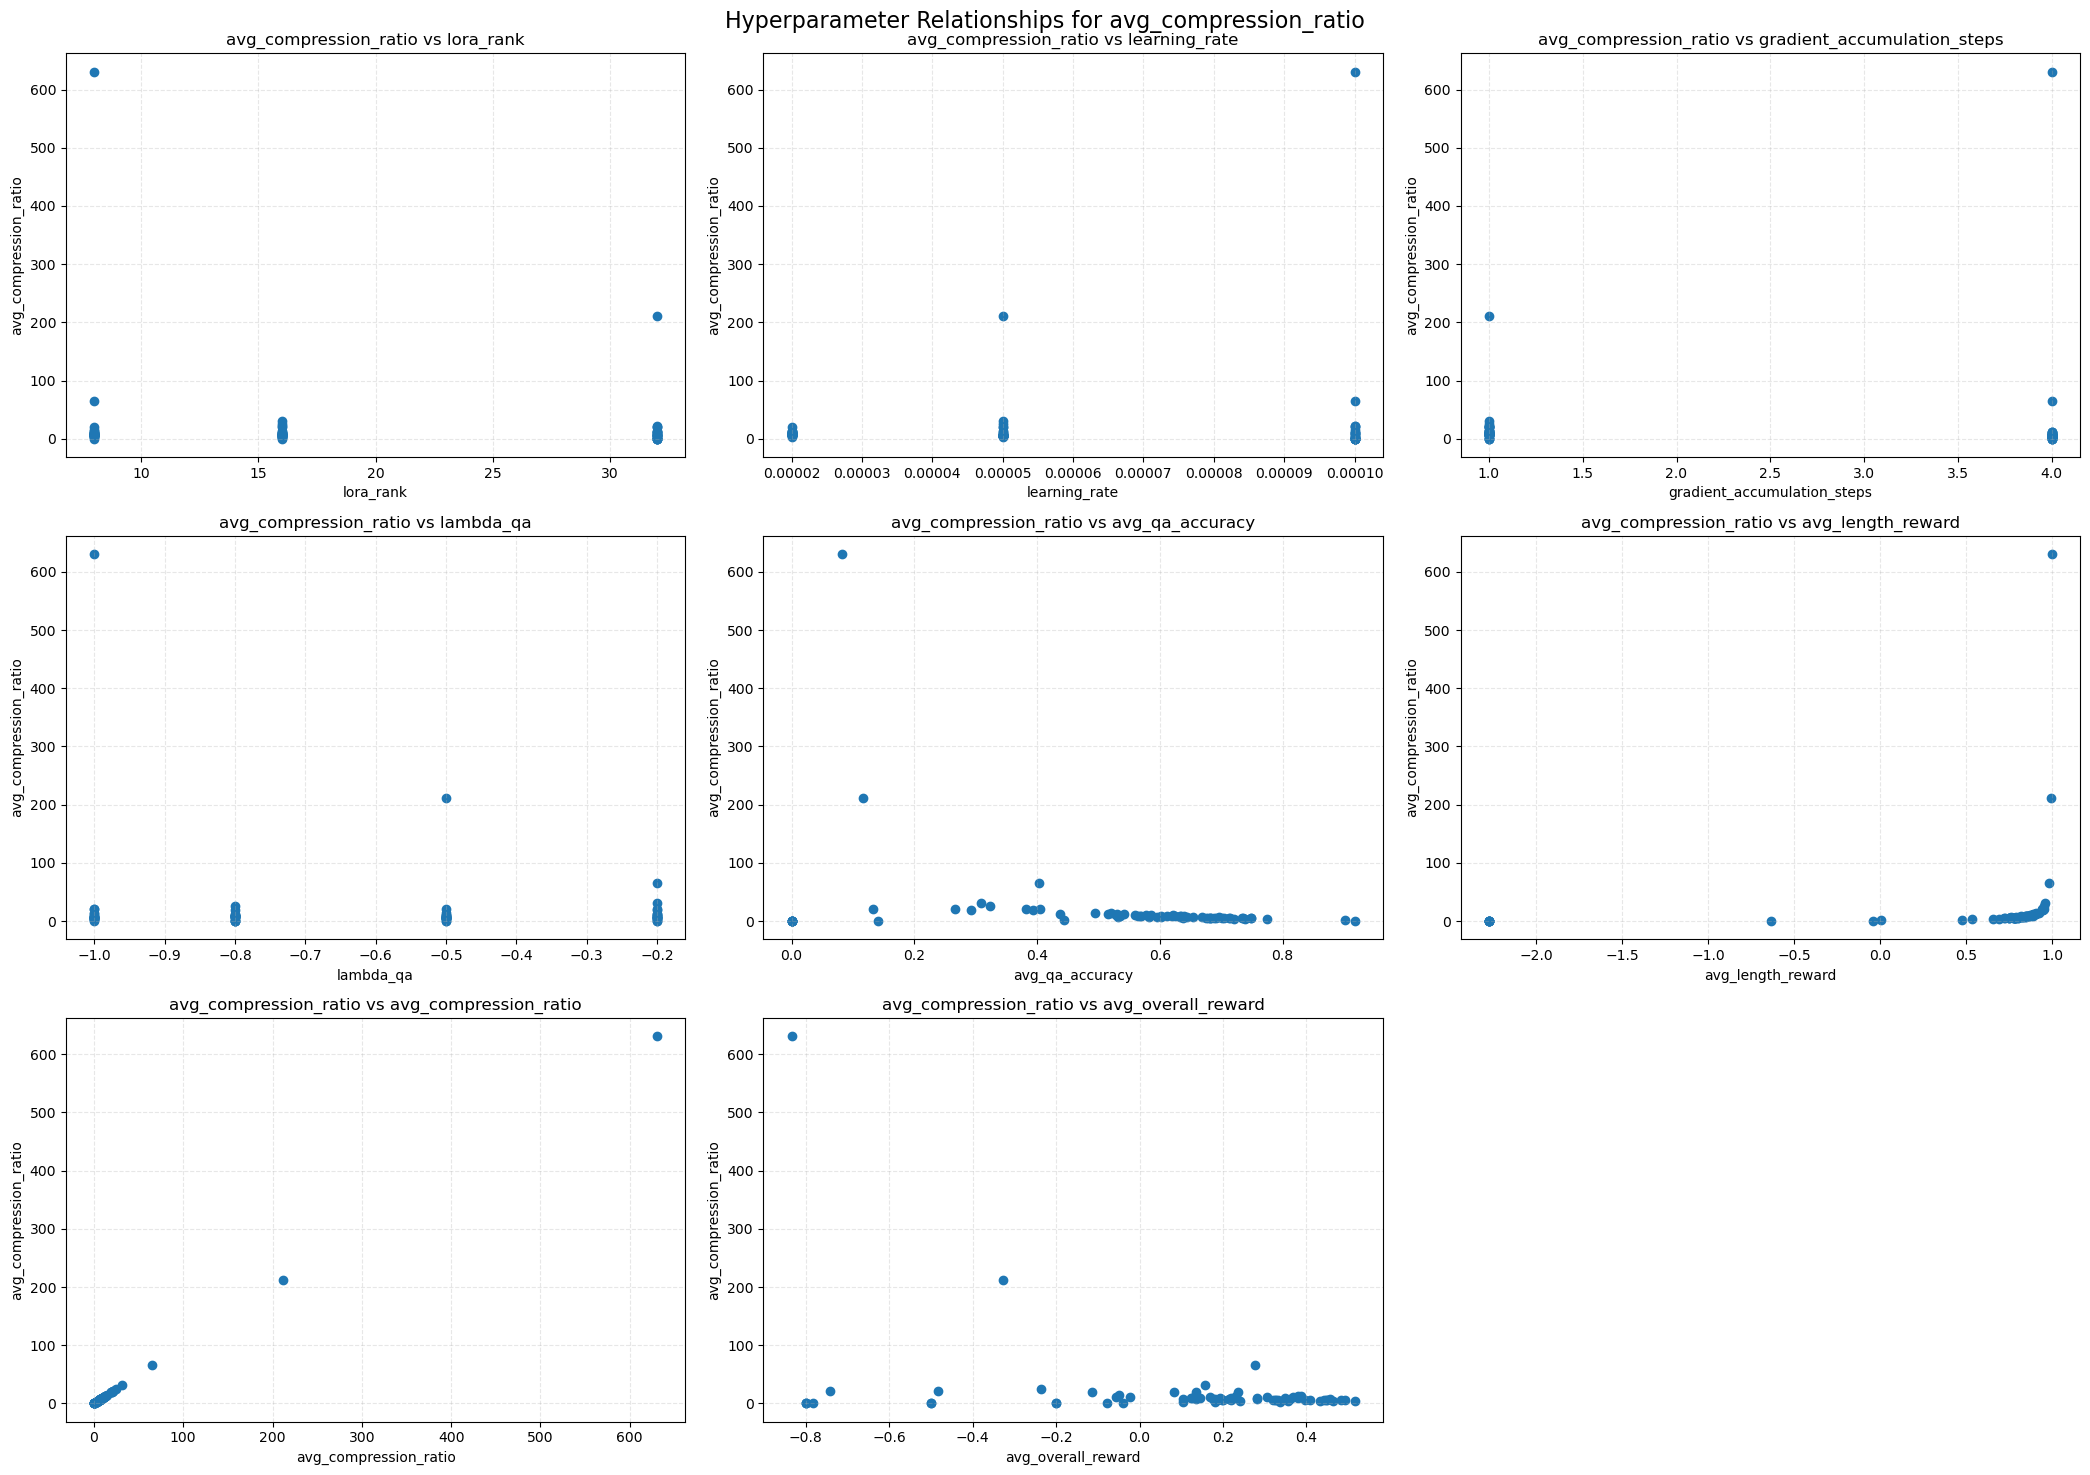

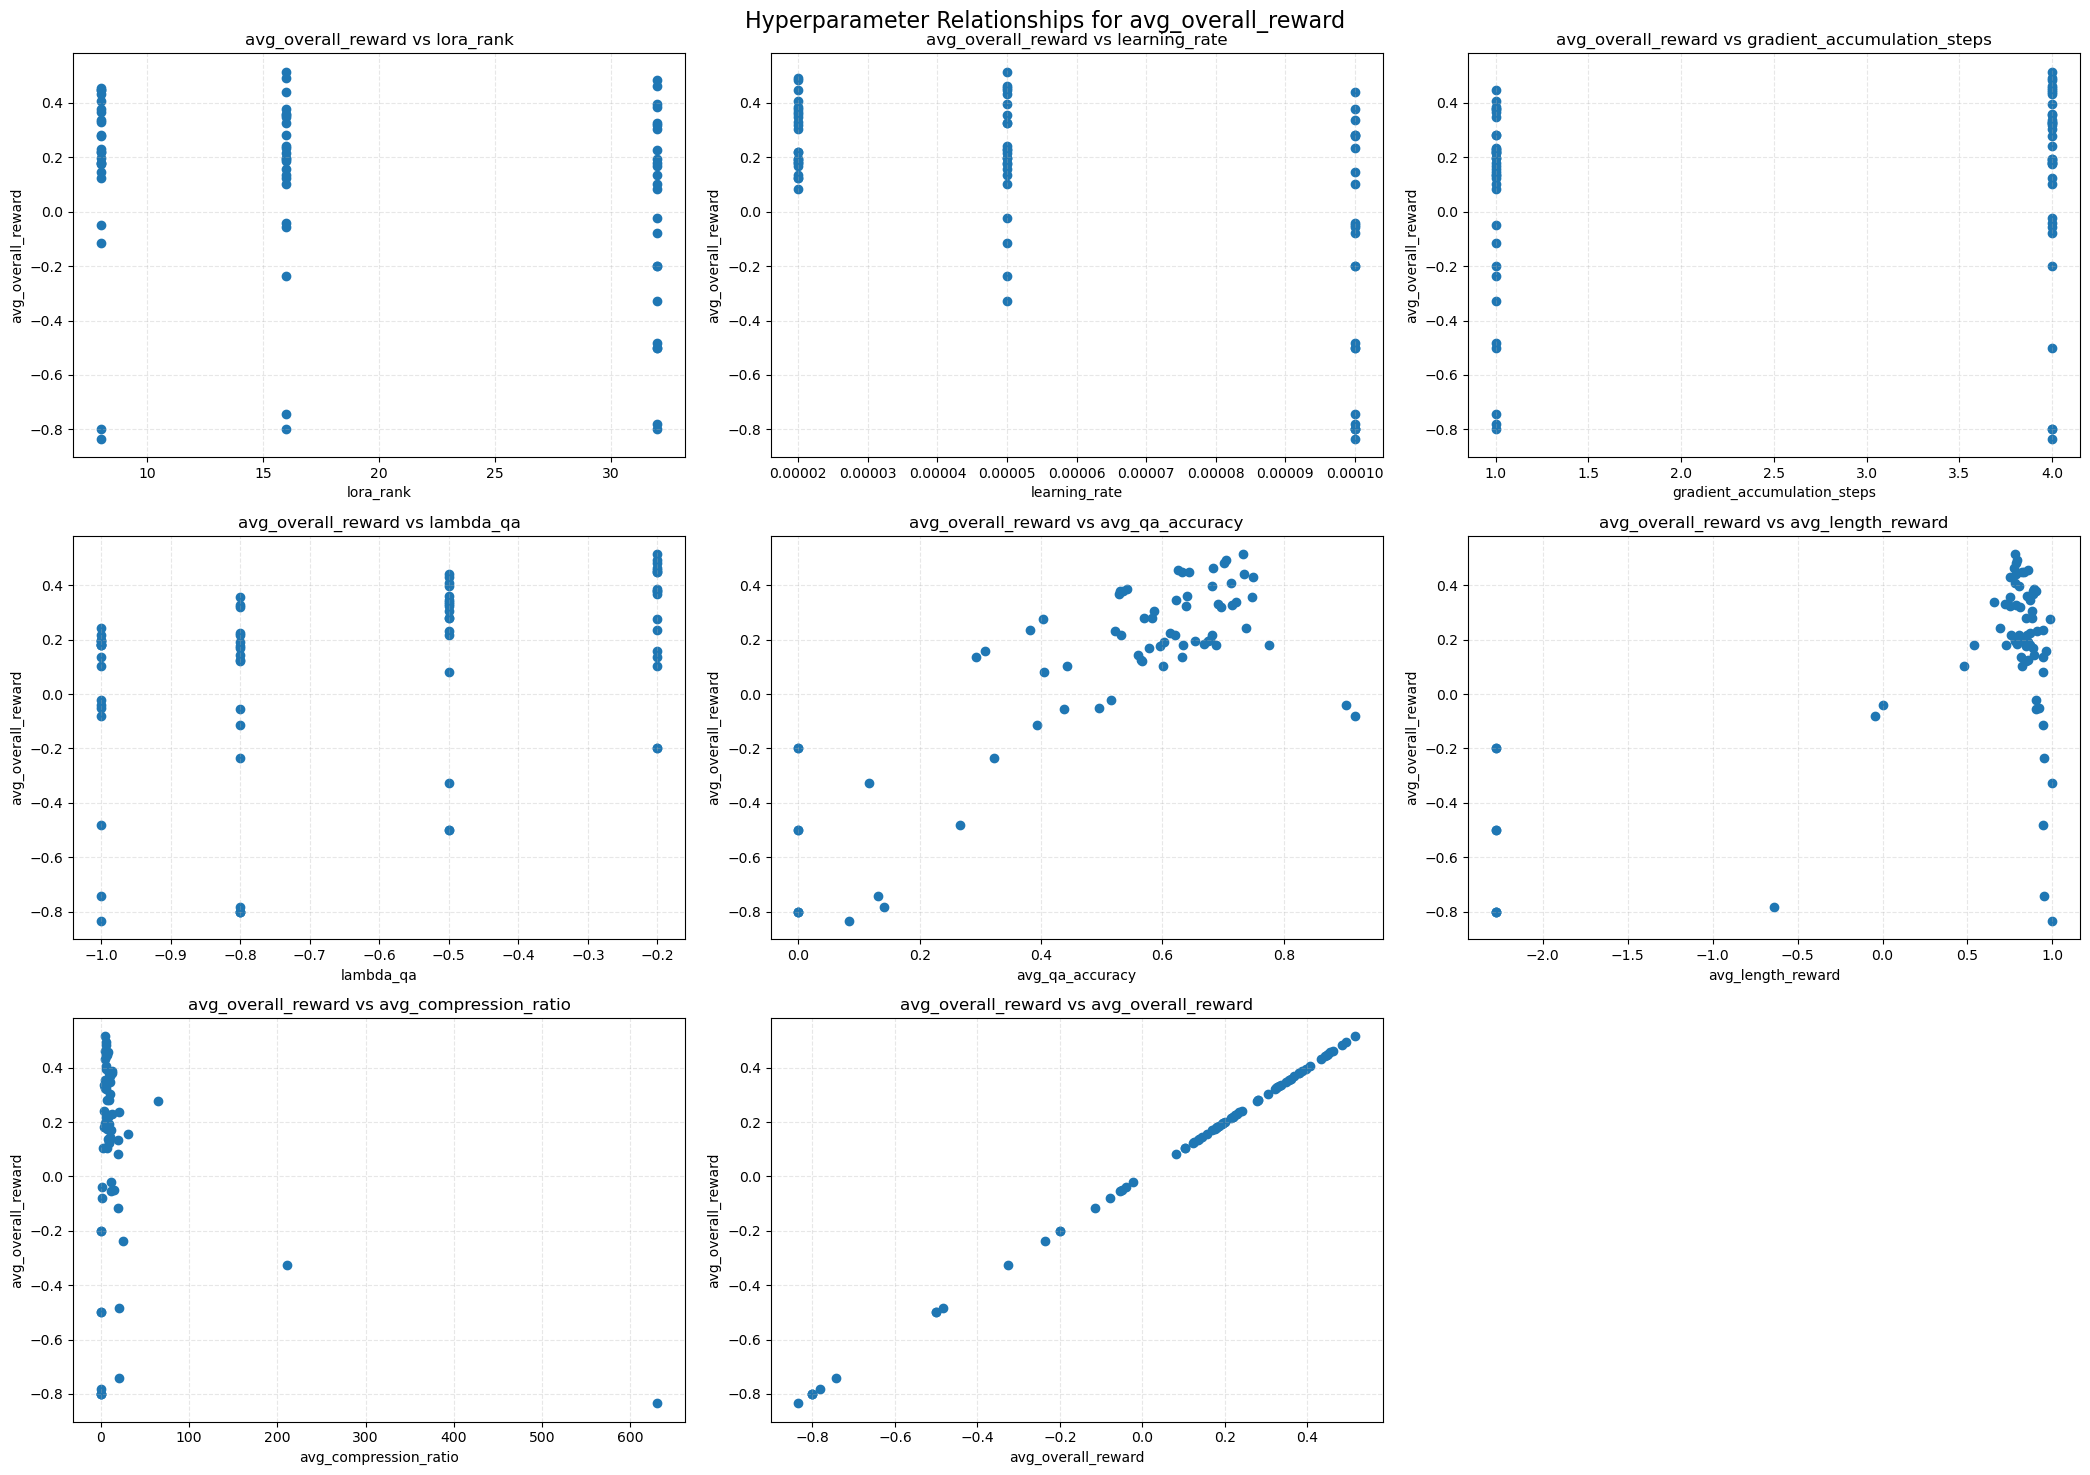

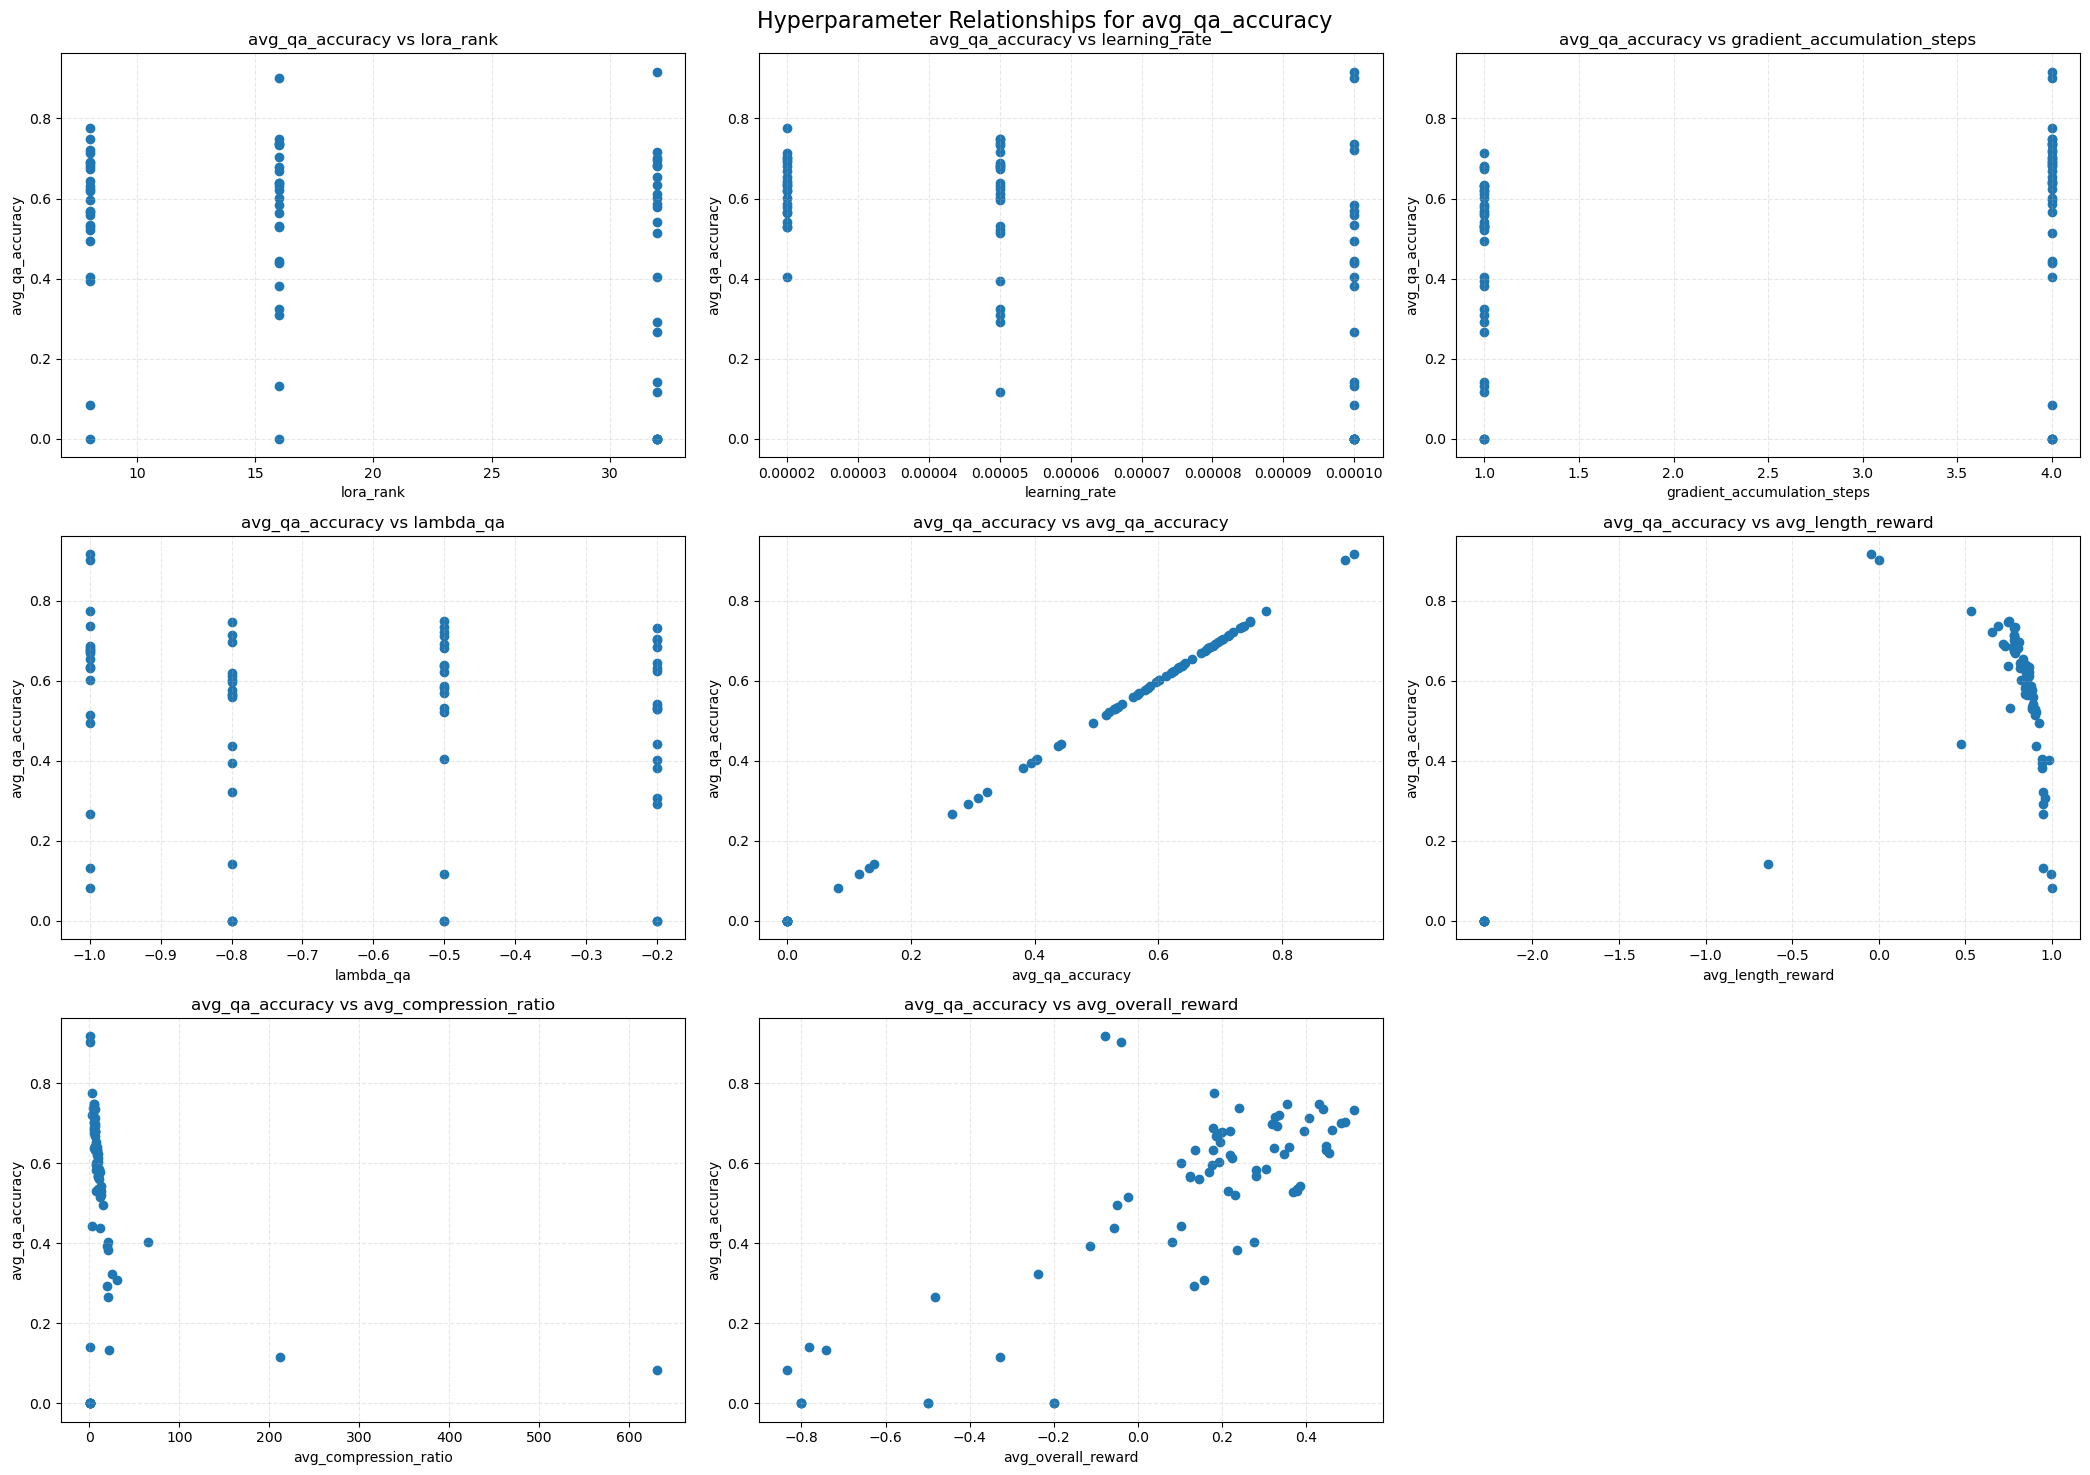

In [6]:
metrics = [
    "avg_compression_ratio",
    "avg_overall_reward",
    "avg_qa_accuracy"
]

numeric_hps = ['lora_rank','learning_rate', 'gradient_accumulation_steps', 'lambda_qa', 'avg_qa_accuracy', 'avg_length_reward', 'avg_compression_ratio', 'avg_overall_reward']


for metric in metrics:
    n = len(numeric_hps)
    cols = 3
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 5*rows))
    axes = axes.flatten()

    for i, hp in enumerate(numeric_hps):
        ax = axes[i]
        ax.scatter(results_df[hp], results_df[metric])
        ax.set_xlabel(hp)
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs {hp}")
        ax.grid(True, linestyle="--", alpha=0.3)

    # hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Hyperparameter Relationships for {metric}", fontsize=16)
    plt.tight_layout()
    plt.show()


In [7]:
results_df.sort_values(by="avg_qa_accuracy", ascending=False).iloc[:2]["experiment_name"].to_list()[0]

'sweep_learning_rate_1eneg04_lora_rank_32_gradient_accumulation_steps_4_lambda_neg1p000'